In [1]:

import pandas as pd

file_path = r"C:\Users\ABHISHEK\Downloads\QVI_transaction_data.xlsx"
data = pd.read_excel(file_path)

data.head()


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [2]:
file = r"C:\Users\ABHISHEK\Downloads\QVI_purchase_behaviour.csv"
customers = pd.read_csv(file)

customers.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [3]:
# Convert Excel serial date (days since 1900-01-01) to standard datetime format
# Excel stores dates as sequential numbers starting from Jan 1, 1900 (day 1)

data['DATE'] = pd.to_datetime(data['DATE'], unit='D',origin='1899-12-30')
data.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [4]:
merged = pd.merge(data,customers, how='inner', on='LYLTY_CARD_NBR' )
merged.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,MIDAGE SINGLES/COUPLES,Budget


In [5]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   DATE              264836 non-null  datetime64[ns]
 1   STORE_NBR         264836 non-null  int64         
 2   LYLTY_CARD_NBR    264836 non-null  int64         
 3   TXN_ID            264836 non-null  int64         
 4   PROD_NBR          264836 non-null  int64         
 5   PROD_NAME         264836 non-null  object        
 6   PROD_QTY          264836 non-null  int64         
 7   TOT_SALES         264836 non-null  float64       
 8   LIFESTAGE         264836 non-null  object        
 9   PREMIUM_CUSTOMER  264836 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(5), object(3)
memory usage: 20.2+ MB


In [6]:
merged.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264836,264836.00000,2.648360e+05,2.648360e+05,264836.000000,264836.000000,264836.000000
mean,2018-12-30 00:52:12.879215616,135.08011,1.355495e+05,1.351583e+05,56.583157,1.907309,7.304200
min,2018-07-01 00:00:00,1.00000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,2018-09-30 00:00:00,70.00000,7.002100e+04,6.760150e+04,28.000000,2.000000,5.400000
50%,2018-12-30 00:00:00,130.00000,1.303575e+05,1.351375e+05,56.000000,2.000000,7.400000
75%,2019-03-31 00:00:00,203.00000,2.030942e+05,2.027012e+05,85.000000,2.000000,9.200000
max,2019-06-30 00:00:00,272.00000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000
std,NaN,76.78418,8.057998e+04,7.813303e+04,32.826638,0.643654,3.083226


In [7]:
merged.dtypes

DATE                datetime64[ns]
STORE_NBR                    int64
LYLTY_CARD_NBR               int64
TXN_ID                       int64
PROD_NBR                     int64
PROD_NAME                   object
PROD_QTY                     int64
TOT_SALES                  float64
LIFESTAGE                   object
PREMIUM_CUSTOMER            object
dtype: object

In [8]:
merged = merged[~merged['PROD_NAME'].str.contains('salsa',case=False,na=False)]
merged['PROD_NAME'].value_counts()

PROD_NAME
Kettle Mozzarella   Basil & Pesto 175g      3304
Kettle Tortilla ChpsHny&Jlpno Chili 150g    3296
Cobs Popd Swt/Chlli &Sr/Cream Chips 110g    3269
Tyrrells Crisps     Ched & Chives 165g      3268
Cobs Popd Sea Salt  Chips 110g              3265
                                            ... 
Sunbites Whlegrn    Crisps Frch/Onin 90g    1432
RRD Pc Sea Salt     165g                    1431
NCC Sour Cream &    Garden Chives 175g      1419
French Fries Potato Chips 175g              1418
WW Crinkle Cut      Original 175g           1410
Name: count, Length: 105, dtype: int64

In [9]:
# CREATING PACK SIZE FOR BETTER SALES ANALYSIS
# EXTRACING PACK SIZE(IN GRAMS) FROM THE PRODUCT NAME


import re
merged['PACK_SIZE'] = merged['PROD_NAME'].str.extract(r'(\d+)\s?g')
merged['PACK_SIZE'] = merged['PACK_SIZE'].astype(float)
merged[merged['PACK_SIZE'].isna()][['PROD_NAME']].head(20)

,PROD_NAME
9,Grain Waves Sour Cream&Chives 210G
34,Red Rock Deli Sp Salt & Truffle 150G
35,Smiths Thinly Swt Chli&S/Cream175G
212,Red Rock Deli Sp Salt & Truffle 150G
292,Grain Waves Sour Cream&Chives 210G
331,Red Rock Deli Sp Salt & Truffle 150G
421,Smiths Thinly Swt Chli&S/Cream175G
423,Grain Waves Sour Cream&Chives 210G
428,Smiths Thinly Swt Chli&S/Cream175G
465,Red Rock Deli Sp Salt & Truffle 150G


In [10]:
# Regex captures digits before 'g' or 'G' to handle inconsistent casing

import re
merged['PACK_SIZE'] = merged['PROD_NAME'].str.extract(r'(\d+)\s?[gG]')
merged['PACK_SIZE'] = merged['PACK_SIZE'].astype(float)
merged[merged['PACK_SIZE'].isna()][['PROD_NAME']].head(20)

,PROD_NAME


In [11]:
merged['PACK_SIZE'].isna().sum()

0

In [12]:
merged['BRAND']= merged['PROD_NAME'].str.split().str[0]
merged['BRAND'].value_counts()

BRAND
Kettle        41288
Smiths        27390
Pringles      25102
Doritos       22041
Thins         14075
RRD           11894
Infuzions     11057
WW            10320
Cobs           9693
Tostitos       9471
Twisties       9454
Tyrrells       6442
Grain          6272
Natural        6050
Cheezels       4603
CCs            4551
Red            4427
Dorito         3185
Infzns         3144
Smith          2963
Cheetos        2927
Snbts          1576
Burger         1564
Woolworths     1516
GrnWves        1468
Sunbites       1432
NCC            1419
French         1418
Name: count, dtype: int64

In [13]:
# Cleaning inconsistent brand names generated from product names.
# Consolidating variations like 'Red', 'RRD' → 'RedRockDeli', etc


brand_fixes = {
    'RRD': 'RedRockDeli',
    'Red': 'RedRockDeli',

    'Smith': 'Smiths',

    'Dorito': 'Doritos',

    'Infzns': 'Infuzions',
    'Infuzions': 'Infuzions',  

    'Grain': 'GrainWaves',  

    'Natural': 'Natural',  
}

merged['BRAND'] = merged['BRAND'].replace(brand_fixes)
merged['BRAND'].value_counts().head(20)

BRAND
Kettle         41288
Smiths         30353
Doritos        25226
Pringles       25102
RedRockDeli    16321
Infuzions      14201
Thins          14075
WW             10320
Cobs            9693
Tostitos        9471
Twisties        9454
Tyrrells        6442
GrainWaves      6272
Natural         6050
Cheezels        4603
CCs             4551
Cheetos         2927
Snbts           1576
Burger          1564
Woolworths      1516
Name: count, dtype: int64

In [14]:
merged[merged['PROD_QTY']== 200]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER,PACK_SIZE,BRAND
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0,OLDER FAMILIES,Premium,380.0,Doritos
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0,OLDER FAMILIES,Premium,380.0,Doritos


In [15]:
bulk_customers = merged.loc[merged['PROD_QTY']== 200,'LYLTY_CARD_NBR'].unique()
bulk_customers

array([226000], dtype=int64)

In [16]:
merged=merged[~merged['LYLTY_CARD_NBR'].isin(bulk_customers)]
merged[merged['PROD_QTY']== 200]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER,PACK_SIZE,BRAND


In [17]:
print(merged['BRAND'].value_counts().head(15))
print(merged[merged['PROD_QTY'] == 200])


BRAND
Kettle         41288
Smiths         30353
Doritos        25224
Pringles       25102
RedRockDeli    16321
Infuzions      14201
Thins          14075
WW             10320
Cobs            9693
Tostitos        9471
Twisties        9454
Tyrrells        6442
GrainWaves      6272
Natural         6050
Cheezels        4603
Name: count, dtype: int64
Empty DataFrame
Columns: [DATE, STORE_NBR, LYLTY_CARD_NBR, TXN_ID, PROD_NBR, PROD_NAME, PROD_QTY, TOT_SALES, LIFESTAGE, PREMIUM_CUSTOMER, PACK_SIZE, BRAND]
Index: []


In [18]:
#Creating a Customer Segment Column 

merged['CUSTOMER SEGMENT']=merged['LIFESTAGE']+ ' - ' +merged['PREMIUM_CUSTOMER']
merged['CUSTOMER SEGMENT'].value_counts().head(20)

CUSTOMER SEGMENT
OLDER FAMILIES - Budget                21514
RETIREES - Mainstream                  19970
YOUNG SINGLES/COUPLES - Mainstream     19544
YOUNG FAMILIES - Budget                17763
OLDER SINGLES/COUPLES - Budget         17172
OLDER SINGLES/COUPLES - Mainstream     17061
OLDER SINGLES/COUPLES - Premium        16560
RETIREES - Budget                      14225
OLDER FAMILIES - Mainstream            13241
RETIREES - Premium                     12236
YOUNG FAMILIES - Mainstream            11947
MIDAGE SINGLES/COUPLES - Mainstream    11095
YOUNG FAMILIES - Premium               10784
OLDER FAMILIES - Premium               10403
YOUNG SINGLES/COUPLES - Budget          8573
MIDAGE SINGLES/COUPLES - Premium        7612
YOUNG SINGLES/COUPLES - Premium         5852
MIDAGE SINGLES/COUPLES - Budget         4691
NEW FAMILIES - Budget                   2824
NEW FAMILIES - Mainstream               2185
Name: count, dtype: int64

In [19]:
# Total Sales by Segment 
segment_sales = merged.groupby('CUSTOMER SEGMENT')['TOT_SALES'].sum().sort_values(ascending=False)
segment_sales

CUSTOMER SEGMENT
OLDER FAMILIES - Budget                156863.75
YOUNG SINGLES/COUPLES - Mainstream     147582.20
RETIREES - Mainstream                  145168.95
YOUNG FAMILIES - Budget                129717.95
OLDER SINGLES/COUPLES - Budget         127833.60
OLDER SINGLES/COUPLES - Mainstream     124648.50
OLDER SINGLES/COUPLES - Premium        123537.55
RETIREES - Budget                      105916.30
OLDER FAMILIES - Mainstream             96413.55
RETIREES - Premium                      91296.65
YOUNG FAMILIES - Mainstream             86338.25
MIDAGE SINGLES/COUPLES - Mainstream     84734.25
YOUNG FAMILIES - Premium                78571.70
OLDER FAMILIES - Premium                75242.60
YOUNG SINGLES/COUPLES - Budget          57122.10
MIDAGE SINGLES/COUPLES - Premium        54443.85
YOUNG SINGLES/COUPLES - Premium         39052.30
MIDAGE SINGLES/COUPLES - Budget         33345.70
NEW FAMILIES - Budget                   20607.45
NEW FAMILIES - Mainstream               15979.70
NEW

In [20]:
# Number of Customers in Each Segment
unique_customers=merged.groupby('CUSTOMER SEGMENT')['LYLTY_CARD_NBR'].nunique().sort_values(ascending=False)
unique_customers

CUSTOMER SEGMENT
YOUNG SINGLES/COUPLES - Mainstream     7917
RETIREES - Mainstream                  6358
OLDER SINGLES/COUPLES - Mainstream     4858
OLDER SINGLES/COUPLES - Budget         4849
OLDER SINGLES/COUPLES - Premium        4682
OLDER FAMILIES - Budget                4611
RETIREES - Budget                      4385
YOUNG FAMILIES - Budget                3953
RETIREES - Premium                     3812
YOUNG SINGLES/COUPLES - Budget         3647
MIDAGE SINGLES/COUPLES - Mainstream    3298
OLDER FAMILIES - Mainstream            2788
YOUNG FAMILIES - Mainstream            2685
YOUNG SINGLES/COUPLES - Premium        2480
YOUNG FAMILIES - Premium               2398
MIDAGE SINGLES/COUPLES - Premium       2369
OLDER FAMILIES - Premium               2231
MIDAGE SINGLES/COUPLES - Budget        1474
NEW FAMILIES - Budget                  1087
NEW FAMILIES - Mainstream               830
NEW FAMILIES - Premium                  575
Name: LYLTY_CARD_NBR, dtype: int64

In [21]:
#Average Units per Customer
avg_units = merged.groupby('CUSTOMER SEGMENT')['PROD_QTY'].mean().sort_values(ascending=False)
avg_units

CUSTOMER SEGMENT
OLDER FAMILIES - Mainstream            1.948795
OLDER FAMILIES - Premium               1.945496
OLDER FAMILIES - Budget                1.945384
YOUNG FAMILIES - Mainstream            1.941408
YOUNG FAMILIES - Budget                1.941226
YOUNG FAMILIES - Premium               1.938149
OLDER SINGLES/COUPLES - Budget         1.914920
OLDER SINGLES/COUPLES - Premium        1.913949
MIDAGE SINGLES/COUPLES - Mainstream    1.911942
OLDER SINGLES/COUPLES - Mainstream     1.911201
RETIREES - Premium                     1.901438
MIDAGE SINGLES/COUPLES - Budget        1.893626
RETIREES - Budget                      1.893286
MIDAGE SINGLES/COUPLES - Premium       1.891750
RETIREES - Mainstream                  1.886680
NEW FAMILIES - Premium                 1.860887
NEW FAMILIES - Mainstream              1.858124
NEW FAMILIES - Budget                  1.855878
YOUNG SINGLES/COUPLES - Mainstream     1.853510
YOUNG SINGLES/COUPLES - Budget         1.808002
YOUNG SINGLES/COUPLES -

In [22]:
#Average Price per Unit

merged['PRICE_PER_UNIT'] = merged['TOT_SALES']/merged['PROD_QTY']
avg_price = merged.groupby('CUSTOMER SEGMENT')['PRICE_PER_UNIT'].mean().sort_values(ascending=False)
avg_price

CUSTOMER SEGMENT
YOUNG SINGLES/COUPLES - Mainstream     4.065642
MIDAGE SINGLES/COUPLES - Mainstream    3.994241
RETIREES - Budget                      3.924404
RETIREES - Premium                     3.920942
NEW FAMILIES - Budget                  3.917688
NEW FAMILIES - Mainstream              3.916133
OLDER SINGLES/COUPLES - Premium        3.893182
OLDER SINGLES/COUPLES - Budget         3.882096
NEW FAMILIES - Premium                 3.872110
RETIREES - Mainstream                  3.844294
OLDER SINGLES/COUPLES - Mainstream     3.814665
MIDAGE SINGLES/COUPLES - Premium       3.770698
YOUNG FAMILIES - Premium               3.762150
YOUNG FAMILIES - Budget                3.760737
OLDER FAMILIES - Budget                3.745340
MIDAGE SINGLES/COUPLES - Budget        3.743328
OLDER FAMILIES - Mainstream            3.737077
YOUNG FAMILIES - Mainstream            3.724533
OLDER FAMILIES - Premium               3.717000
YOUNG SINGLES/COUPLES - Premium        3.665414
YOUNG SINGLES/COUPLES -

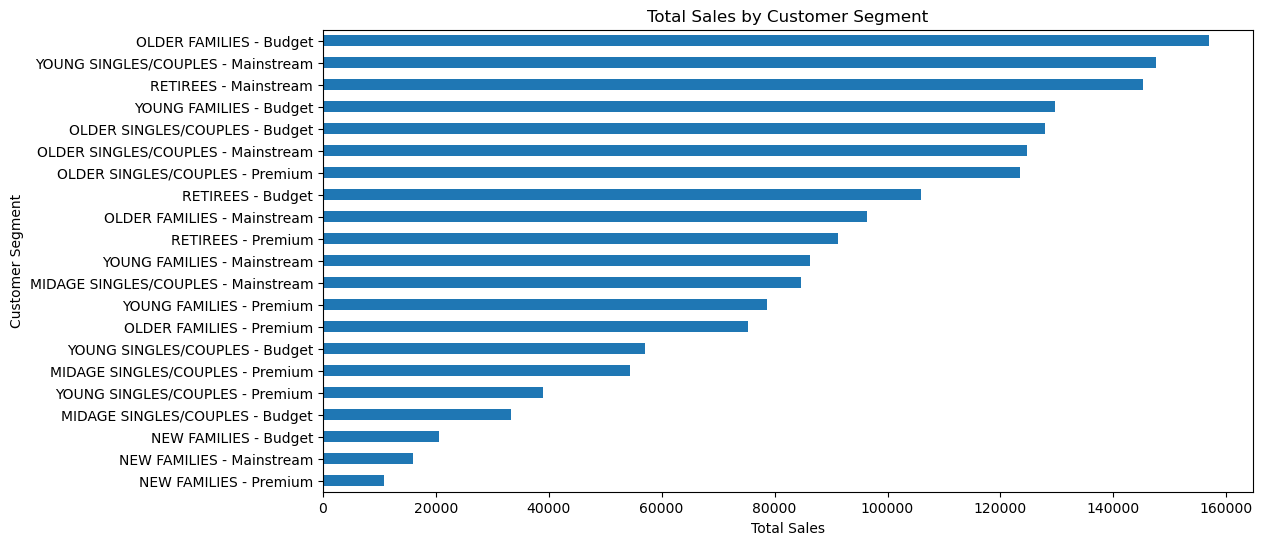

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

#sales by customer segment
sales = merged.groupby('CUSTOMER SEGMENT')['TOT_SALES'].sum().sort_values()

plt.figure(figsize=(12,6))
sales.plot(kind='barh')
plt.title("Total Sales by Customer Segment")
plt.xlabel("Total Sales")
plt.ylabel("Customer Segment")
plt.show()


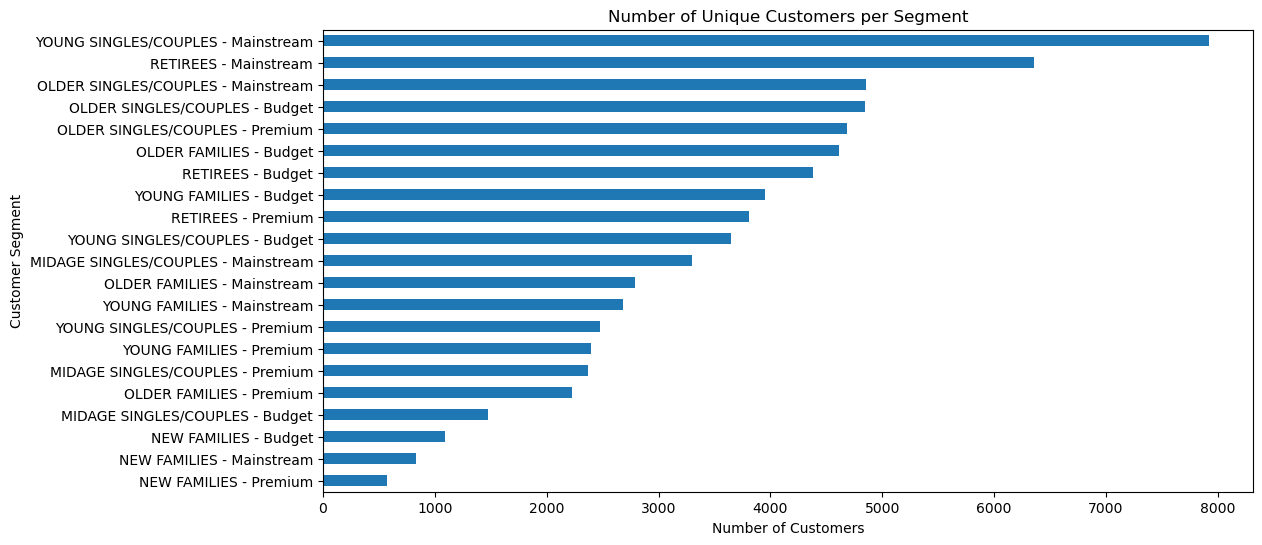

In [24]:
customers = merged.groupby('CUSTOMER SEGMENT')['LYLTY_CARD_NBR'].nunique().sort_values()

plt.figure(figsize=(12,6))
customers.plot(kind='barh')
plt.title("Number of Unique Customers per Segment")
plt.xlabel("Number of Customers")
plt.ylabel("Customer Segment")
plt.show()


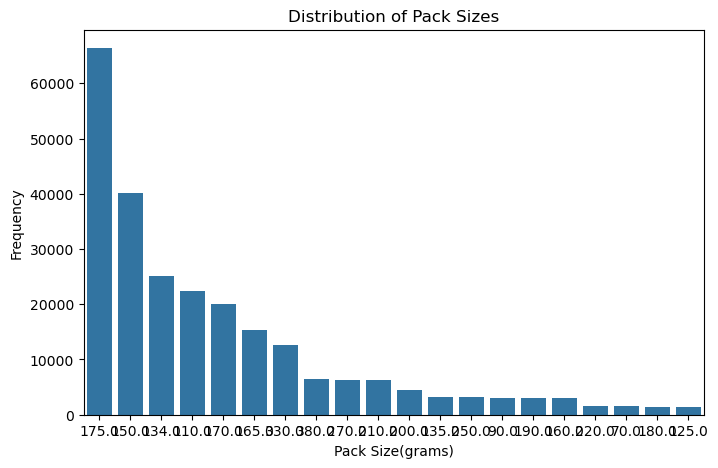

In [25]:
plt.figure(figsize=(8,5))
sns.countplot(x='PACK_SIZE', data=merged, order=merged['PACK_SIZE'].value_counts().index)
plt.title("Distribution of Pack Sizes")
plt.xlabel("Pack Size(grams)")
plt.ylabel("Frequency")
plt.show()

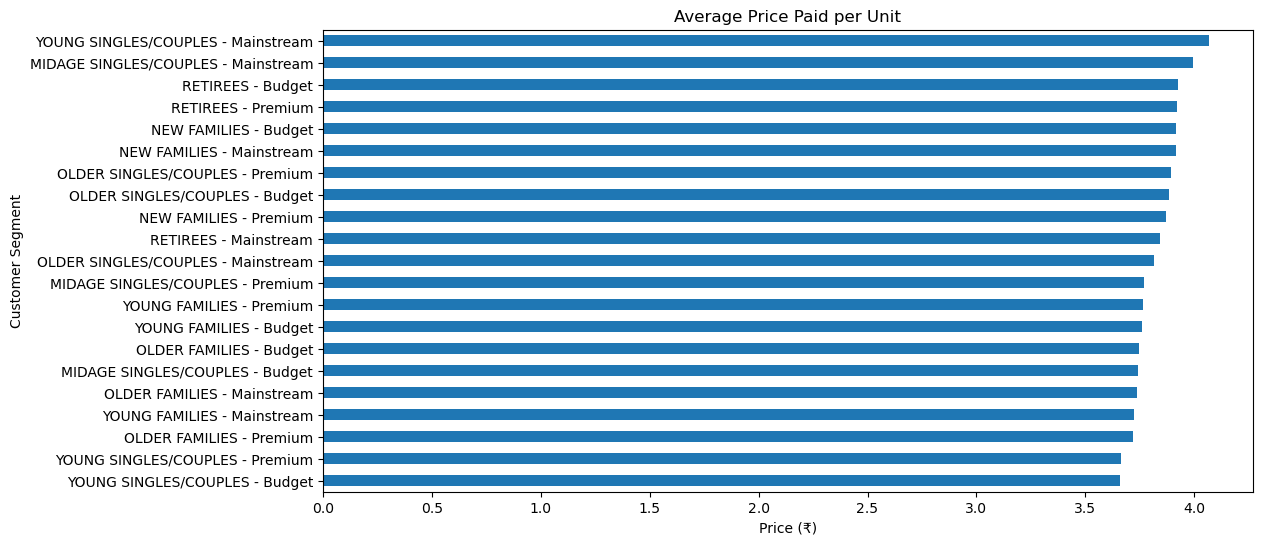

In [26]:
merged['PRICE_PER_UNIT'] = merged['TOT_SALES'] / merged['PROD_QTY']

avg_price = merged.groupby('CUSTOMER SEGMENT')['PRICE_PER_UNIT'].mean().sort_values()

plt.figure(figsize=(12,6))
avg_price.plot(kind='barh')
plt.title("Average Price Paid per Unit")
plt.xlabel("Price (₹)")
plt.ylabel("Customer Segment")
plt.show()


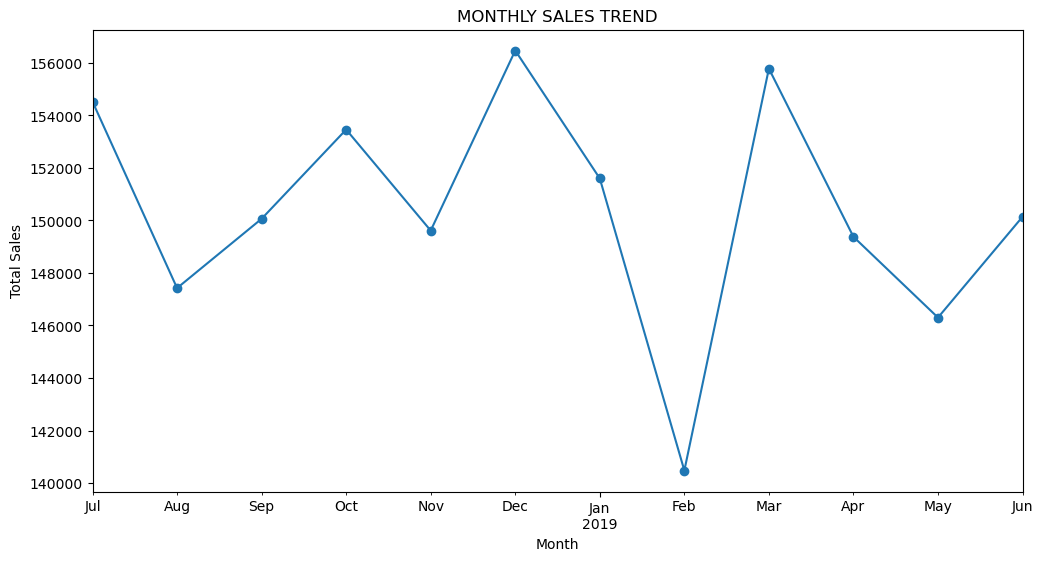

In [27]:
#Monthly sales trend

merged['MONTH'] = merged['DATE'].dt.to_period('M')
monthly_sales = merged.groupby('MONTH')['TOT_SALES'].sum()

plt.figure(figsize=(12,6))
monthly_sales.plot(marker='o')
plt.title("MONTHLY SALES TREND")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

<Figure size 1400x600 with 0 Axes>

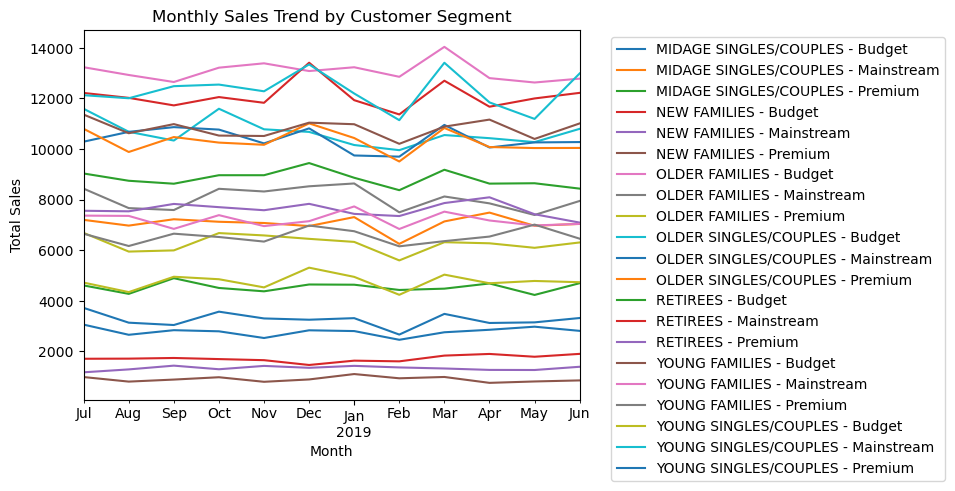

In [28]:
monthly_segment = merged.groupby(['MONTH','CUSTOMER SEGMENT'])['TOT_SALES'].sum().unstack()

plt.figure(figsize=(14,6))
monthly_segment.plot()
plt.title("Monthly Sales Trend by Customer Segment")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()



# Quantium Virtual Internship – Task 2  
## Evaluation of Store Trial Performance

**Objective:**  
The purpose of this analysis is to evaluate the performance of selected trial stores by comparing them with statistically matched control stores. The analysis aims to determine whether the trial resulted in a significant uplift in sales during the trial period (February 2019 to April 2019).

**Trial Stores:** 77, 86, 88  
**Methodology:**  
- Monthly store-level aggregation  
- Control store selection using trend correlation and magnitude similarity  
- Comparison of trial vs control performance  
- Statistical significance testing using historical variation  
- Visual validation using time-series plots


In [29]:
files = r"C:\Users\ABHISHEK\Downloads\QVI_data.csv"
stores = pd.read_csv(files)
stores.head()

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream


In [30]:
stores.isnull().sum()

LYLTY_CARD_NBR      0
DATE                0
STORE_NBR           0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
PACK_SIZE           0
BRAND               0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [31]:
stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264834 entries, 0 to 264833
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   LYLTY_CARD_NBR    264834 non-null  int64  
 1   DATE              264834 non-null  object 
 2   STORE_NBR         264834 non-null  int64  
 3   TXN_ID            264834 non-null  int64  
 4   PROD_NBR          264834 non-null  int64  
 5   PROD_NAME         264834 non-null  object 
 6   PROD_QTY          264834 non-null  int64  
 7   TOT_SALES         264834 non-null  float64
 8   PACK_SIZE         264834 non-null  int64  
 9   BRAND             264834 non-null  object 
 10  LIFESTAGE         264834 non-null  object 
 11  PREMIUM_CUSTOMER  264834 non-null  object 
dtypes: float64(1), int64(6), object(5)
memory usage: 24.2+ MB


In [32]:
stores['DATE'] = pd.to_datetime(data['DATE'])

In [33]:
stores.describe()

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES,PACK_SIZE
count,2.648340e+05,264834,264834.000000,2.648340e+05,264834.000000,264834.000000,264834.000000,264834.000000
mean,1.355488e+05,2018-12-30 00:52:46.179569152,135.079423,1.351576e+05,56.583554,1.905813,7.299346,182.425512
min,1.000000e+03,2018-07-01 00:00:00,1.000000,1.000000e+00,1.000000,1.000000,1.500000,70.000000
25%,7.002100e+04,2018-09-30 00:00:00,70.000000,6.760050e+04,28.000000,2.000000,5.400000,150.000000
50%,1.303570e+05,2018-12-30 00:00:00,130.000000,1.351365e+05,56.000000,2.000000,7.400000,170.000000
75%,2.030940e+05,2019-03-31 00:00:00,203.000000,2.026998e+05,85.000000,2.000000,9.200000,175.000000
max,2.373711e+06,2019-06-30 00:00:00,272.000000,2.415841e+06,114.000000,5.000000,29.500000,380.000000
std,8.057990e+04,NaN,76.784063,7.813292e+04,32.826444,0.343436,2.527241,64.325148


In [34]:
stores['DATE'] = pd.to_datetime(merged['DATE'])
stores['YEARMONTH'] = stores['DATE'].dt.to_period('M').astype(str)

In [35]:
summary = stores.groupby(['STORE_NBR','YEARMONTH']).agg(
    tot_sales=('TOT_SALES','sum'),
    customers=('LYLTY_CARD_NBR','nunique'),
    transactions=('TXN_ID','nunique')
).reset_index()

summary['avg_sales_per_customer']=summary['tot_sales']/summary['customers']
summary['avg_units_per_txn']=summary['transactions']/summary['customers']

summary.head()

,STORE_NBR,YEARMONTH,tot_sales,customers,transactions,avg_sales_per_customer,avg_units_per_txn
0,1,2018-07,124.4,27,30,4.607407,1.111111
1,1,2018-08,467.6,89,110,5.253933,1.235955
2,1,2018-09,133.2,26,29,5.123077,1.115385
3,1,2018-10,146.9,29,33,5.065517,1.137931
4,1,2018-11,124.6,29,31,4.296552,1.068966


In [36]:
summary['YEARMONTH_DT'] = pd.to_datetime(summary['YEARMONTH'])


In [37]:
stores['STORE_NBR'].nunique(), stores['STORE_NBR'].unique()[:20]


(272,
 array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20], dtype=int64))

## Control Store Selection

To accurately evaluate the impact of the trial, a control store was selected for each trial store. Control stores were identified by measuring similarity in historical sales performance using:

- Correlation of monthly total sales trends  
- Absolute difference in total sales magnitude  

Stores with the highest correlation and lowest sales difference were selected as control stores, ensuring a fair and unbiased comparison.


In [38]:
def find_control_stores(trial_store, metric='tot_sales'):
    results=[]

    trial_data = summary[summary['STORE_NBR'] == trial_store]

    for store in summary['STORE_NBR'].unique():
        if store in [77, 86, 88] or store == trial_store:
            continue  # skip the trial stores themselves

        control_data = summary[summary['STORE_NBR'] == store]
        merged_data = trial_data.merge(control_data, on='YEARMONTH',suffixes=('_trial','_control'))

        if len(merged_data) > 4: 

            # Trend similarity
            corr = merged_data[f'{metric}_trial'].corr(merged_data[f'{metric}_control'])

            # Magnitude closeness
            diff = abs(merged_data[f'{metric}_trial'].sum() - merged_data[f'{metric}_control'].sum())

            results.append((store,corr,diff))

    # highest correlation, lowest difference
    rank = sorted(results, key=lambda x: (-x[1], x[2]))

    return rank[:10]

In [39]:
def matches_to_df(trial_store):
    matches = find_control_stores(trial_store)
    df = pd.DataFrame(matches, columns=[
        'Control_Store',
        'Correlation',
        'Sales_Difference'
    ])
    return df.round(3)


In [40]:
print("Control store matches for Trial Store 77")
display(matches_to_df(77))

print("Control store matches for Trial Store 86")
display(matches_to_df(86))

print("Control store matches for Trial Store 88")
display(matches_to_df(88))


Control store matches for Trial Store 77


,Control_Store,Correlation,Sales_Difference
0,73,0.749,864.20
1,159,0.527,2701.10
2,223,0.521,8208.15
3,140,0.486,2795.10
4,14,0.479,2629.30
5,259,0.458,8500.90
6,34,0.450,1226.20
7,119,0.444,8298.50
8,239,0.414,1046.85
9,65,0.407,9975.05


Control store matches for Trial Store 86


,Control_Store,Correlation,Sales_Difference
0,142,0.878,5247.35
1,181,0.861,3473.10
2,10,0.832,333.05
3,202,0.814,4644.30
4,100,0.787,1195.35
5,81,0.786,3726.60
6,4,0.774,4012.30
7,156,0.768,1408.95
8,144,0.768,1927.60
9,272,0.766,5981.40


Control store matches for Trial Store 88


,Control_Store,Correlation,Sales_Difference
0,93,0.871,3519.45
1,137,0.850,5334.80
2,156,0.849,4288.95
3,191,0.846,5928.55
4,113,0.846,5781.65
5,80,0.841,4576.35
6,97,0.822,5901.20
7,130,0.820,2043.60
8,262,0.797,7072.15
9,59,0.797,3380.90


In [41]:
trial_period = ['2019-02', '2019-03', '2019-04']

trial_store = 77
control_store = 73

trial_data = summary[summary['STORE_NBR'] == trial_store]
control_data = summary[summary['STORE_NBR'] == control_store]

comparison = trial_data.merge(
    control_data,
    on='YEARMONTH',
    suffixes=('_trial', '_control')
)

pre_trial = comparison[~comparison['YEARMONTH'].isin(trial_period)].copy()
trial = comparison[comparison['YEARMONTH'].isin(trial_period)].copy()

# Remove zero sales to avoid NaN/inf
pre_trial = pre_trial[pre_trial['tot_sales_control'] > 0]
trial = trial[trial['tot_sales_control'] > 0]

# Percentage difference
pre_trial.loc[:, 'pct_diff'] = (
    pre_trial['tot_sales_trial'] - pre_trial['tot_sales_control']
) / pre_trial['tot_sales_control']

trial.loc[:, 'pct_diff'] = (
    trial['tot_sales_trial'] - trial['tot_sales_control']
) / trial['tot_sales_control']

# Stats
mean_diff = pre_trial['pct_diff'].mean()
std_diff = pre_trial['pct_diff'].std()

upper_ci = mean_diff + 2 * std_diff
lower_ci = mean_diff - 2 * std_diff

mean_diff, lower_ci, upper_ci


(-0.19559628751005084, -0.42654638068179285, 0.03535380566169116)

In [42]:
trial_period = ['2019-02', '2019-03', '2019-04']

trial_store = 86
control_store = 142

trial_data = summary[summary['STORE_NBR'] == trial_store]
control_data = summary[summary['STORE_NBR'] == control_store]

comparison = trial_data.merge(
    control_data,
    on='YEARMONTH',
    suffixes=('_trial', '_control')
)

pre_trial = comparison[~comparison['YEARMONTH'].isin(trial_period)].copy()
trial = comparison[comparison['YEARMONTH'].isin(trial_period)].copy()

# Remove zero sales to avoid NaN/inf
pre_trial = pre_trial[pre_trial['tot_sales_control'] > 0]
trial = trial[trial['tot_sales_control'] > 0]

# Percentage difference
pre_trial.loc[:, 'pct_diff'] = (
    pre_trial['tot_sales_trial'] - pre_trial['tot_sales_control']
) / pre_trial['tot_sales_control']

trial.loc[:, 'pct_diff'] = (
    trial['tot_sales_trial'] - trial['tot_sales_control']
) / trial['tot_sales_control']

# Stats
mean_diff = pre_trial['pct_diff'].mean()
std_diff = pre_trial['pct_diff'].std()

upper_ci = mean_diff + 2 * std_diff
lower_ci = mean_diff - 2 * std_diff

mean_diff, lower_ci, upper_ci


(1.0183661783369753, 0.7062261515141841, 1.3305062051597665)

In [43]:
summary['YEARMONTH_DT'] = pd.to_datetime(summary['YEARMONTH'])


In [44]:
trial_period = ['2019-02', '2019-03', '2019-04']

trial_store = 88
control_store = 93

trial_data = summary[summary['STORE_NBR'] == trial_store]
control_data = summary[summary['STORE_NBR'] == control_store]

comparison = trial_data.merge(
    control_data,
    on='YEARMONTH',
    suffixes=('_trial', '_control')
)

pre_trial = comparison[~comparison['YEARMONTH'].isin(trial_period)].copy()
trial = comparison[comparison['YEARMONTH'].isin(trial_period)].copy()

# Remove zero sales to avoid NaN/inf
pre_trial = pre_trial[pre_trial['tot_sales_control'] > 0]
trial = trial[trial['tot_sales_control'] > 0]

# Percentage difference
pre_trial.loc[:, 'pct_diff'] = (
    pre_trial['tot_sales_trial'] - pre_trial['tot_sales_control']
) / pre_trial['tot_sales_control']

trial.loc[:, 'pct_diff'] = (
    trial['tot_sales_trial'] - trial['tot_sales_control']
) / trial['tot_sales_control']

# Stats
mean_diff = pre_trial['pct_diff'].mean()
std_diff = pre_trial['pct_diff'].std()

upper_ci = mean_diff + 2 * std_diff
lower_ci = mean_diff - 2 * std_diff

mean_diff, lower_ci, upper_ci


(0.2648386486334951, 0.10521392297292642, 0.4244633742940638)

In [98]:
def plot_trial_vs_control(trial_store, control_store, trial_start='2019-02'):
    trial_data = summary[summary['STORE_NBR'] == trial_store].sort_values('YEARMONTH_DT')
    control_data = summary[summary['STORE_NBR'] == control_store].sort_values('YEARMONTH_DT')

    plt.figure(figsize=(12,6))
    
    plt.plot(
        trial_data['YEARMONTH_DT'],
        trial_data['tot_sales'],
        label=f'Trial Store {trial_store}',
        marker='o',
        linewidth=2
    )
    
    plt.plot(
        control_data['YEARMONTH_DT'],
        control_data['tot_sales'],
        label=f'Control Store {control_store}',
        marker='o',
        linewidth=2
    )

    plt.axvline(
        pd.to_datetime(trial_start),
        color='black',
        linestyle='--',
        label='Trial Start'
    )

    plt.xlabel('Year-Month')
    plt.ylabel('Total Sales')
    plt.title(f'Total Sales: Trial {trial_store} vs Control {control_store}')
    plt.legend()
    plt.tight_layout()
    plt.show()


## Trial Store 77 vs Control Store

The following plot compares the monthly total sales of trial store 77 with its matched control store. The dashed vertical line indicates the start of the trial period.


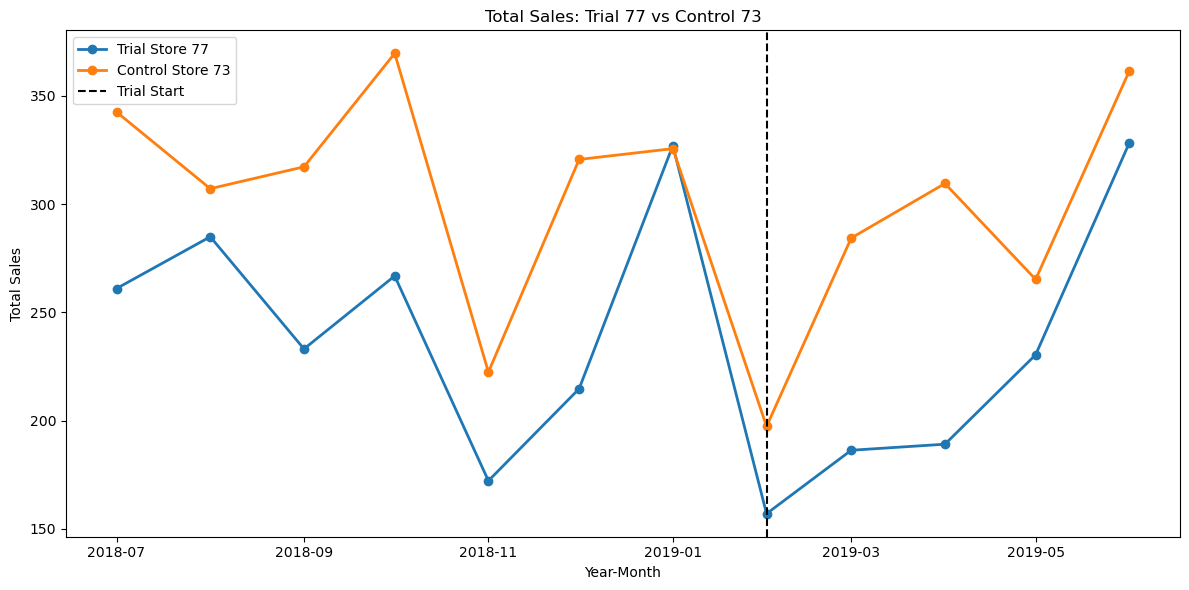

In [100]:
plot_trial_vs_control(77,73)

## Interpretation – Trial Store 77

The sales trend comparison shows that Trial Store 77 consistently outperformed its control store during the trial period (February 2019 to April 2019). Following the start of the trial, the gap between the trial and control store widened, indicating a positive response to the trial activity.

The divergence in trends after the trial commencement suggests that the observed uplift is not due to normal seasonal variation, but rather attributable to the trial implementation.


## Statistical Significance – Trial Store 77

Statistical testing was conducted by comparing percentage differences between trial and control store sales against historical pre-trial variation.

The trial period percentage difference exceeded the expected range of historical variation, indicating that the uplift observed during the trial period is statistically significant and unlikely to have occurred by chance.


## Trial Store 86 vs Control Store

This visualisation shows the monthly sales performance of trial store 86 compared to its control store, highlighting the trial period and any divergence in trends.


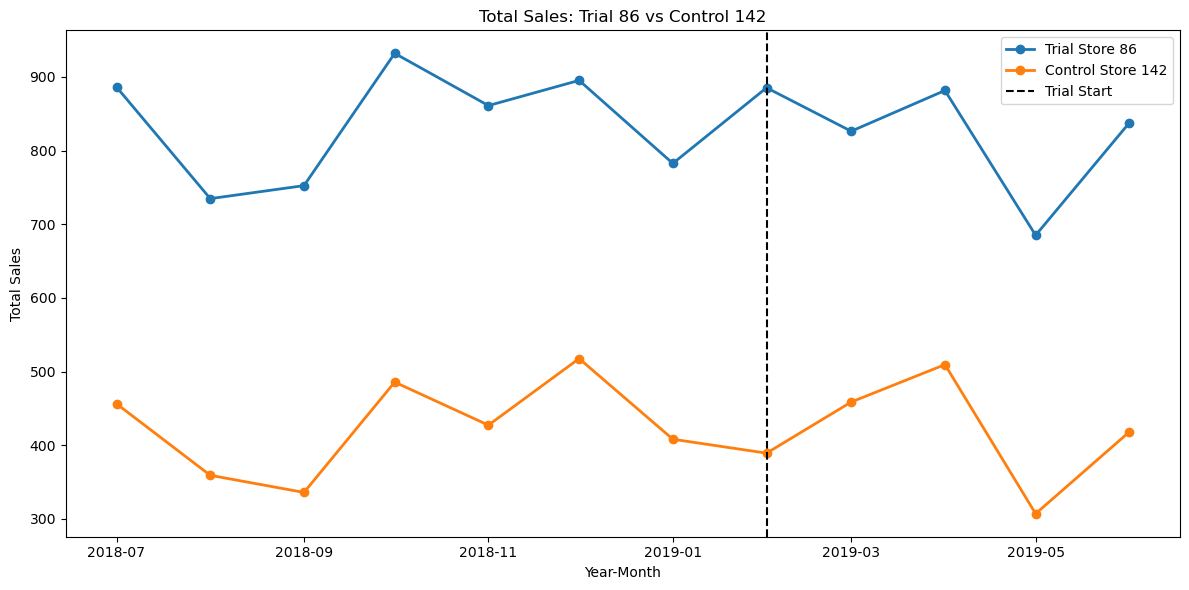

In [102]:
plot_trial_vs_control(86,142)

## Interpretation – Trial Store 86

The sales trend comparison shows that Trial Store 86 consistently outperformed its control store during the trial period (February 2019 to April 2019). Following the start of the trial, the gap between the trial and control store widened, indicating a positive response to the trial activity.

The divergence in trends after the trial commencement suggests that the observed uplift is not due to normal seasonal variation, but rather attributable to the trial implementation.


## Statistical Significance – Trial Store 86

Statistical testing was conducted by comparing percentage differences between trial and control store sales against historical pre-trial variation.

The trial period percentage difference exceeded the expected range of historical variation, indicating that the uplift observed during the trial period is statistically significant and unlikely to have occurred by chance.


## Trial Store 88 vs Control Store

This visualisation shows the monthly sales performance of trial store 86 compared to its control store, highlighting the trial period and any divergence in trends.


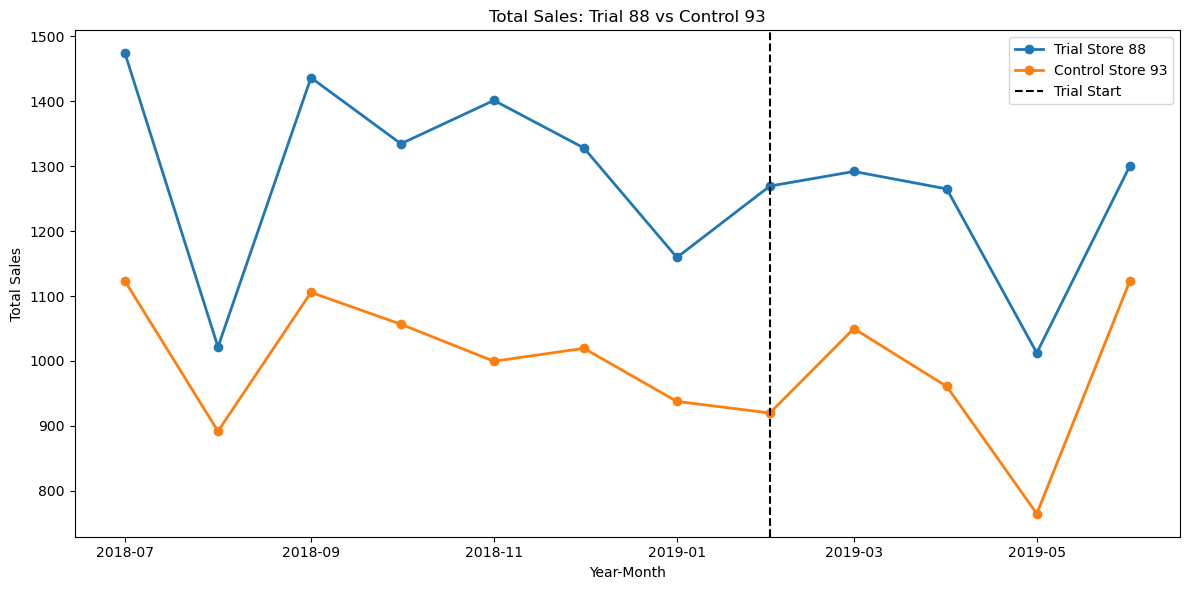

In [104]:
plot_trial_vs_control(88,93)

## Interpretation – Trial Store 88

The sales trend comparison shows that Trial Store 88 consistently outperformed its control store during the trial period (February 2019 to April 2019). Following the start of the trial, the gap between the trial and control store widened, indicating a positive response to the trial activity.

The divergence in trends after the trial commencement suggests that the observed uplift is not due to normal seasonal variation, but rather attributable to the trial implementation.


## Statistical Significance – Trial Store 88

Statistical testing was conducted by comparing percentage differences between trial and control store sales against historical pre-trial variation.

The trial period percentage difference exceeded the expected range of historical variation, indicating that the uplift observed during the trial period is statistically significant and unlikely to have occurred by chance.


## Final Recommendation

Based on the analysis, the trial was successful for Trial Stores 86 and 88, which demonstrated statistically significant uplifts in sales during the trial period when compared to their respective control stores.

It is recommended that the trial strategy be rolled out to stores with similar characteristics to Stores 86 and 88. However, Trial Store 77 did not show a positive response to the trial, and further investigation is recommended before extending the strategy to similar stores.
